In [8]:
import pandas as pd
import paths  # adjust names to your paths.py

player_frame_table = pd.read_parquet(paths.PLAYER_FRAME_TABLE_CACHE_PATH)
ball_frame_table = pd.read_parquet(paths.BALL_FRAME_TABLE_CACHE_PATH)

for name, df in [("player_frame_table", player_frame_table), ("ball_frame_table", ball_frame_table)]:
    print(f"\n===== {name} =====")
    print("shape:", df.shape)
    print("columns:", list(df.columns))
    print("\ndtypes:\n", df.dtypes)
    print("\nnull counts:\n", df.isna().sum())
    display(df.head(10))


===== player_frame_table =====
shape: (1592449, 10)
columns: ['frame_idx', 'track_id', 'role', 'team', 'x_px', 'y_px', 'pitch_x', 'pitch_y', 'is_carrier', 'attack_direction']

dtypes:
 frame_idx             int64
track_id              int64
role                 object
team                  Int64
x_px                float64
y_px                float64
pitch_x             float64
pitch_y             float64
is_carrier             bool
attack_direction      Int64
dtype: object

null counts:
 frame_idx                0
track_id                 0
role                     0
team                177582
x_px                     0
y_px                     0
pitch_x               3439
pitch_y               3439
is_carrier               0
attack_direction    177582
dtype: int64


,frame_idx,track_id,role,team,x_px,y_px,pitch_x,pitch_y,is_carrier,attack_direction
0,0,1,referee,<NA>,1726.915649,969.055847,NaN,NaN,False,<NA>
1,0,2,referee,<NA>,1048.446899,610.321533,NaN,NaN,False,<NA>
2,0,3,referee,<NA>,672.636353,302.925354,NaN,NaN,False,<NA>
3,0,4,player,0,929.178589,708.090942,NaN,NaN,False,1
4,0,5,player,1,950.553406,618.163818,NaN,NaN,False,-1
5,0,6,player,1,1031.554932,685.750122,NaN,NaN,False,-1
6,0,7,player,1,1202.902344,381.230591,NaN,NaN,False,-1
7,0,10,player,1,1238.631592,652.587402,NaN,NaN,False,-1
8,0,11,player,0,555.291809,696.930786,NaN,NaN,False,1
9,0,12,player,0,518.595825,577.895630,NaN,NaN,False,1



===== ball_frame_table =====
shape: (70326, 10)
columns: ['frame_idx', 'ball_x_px', 'ball_y_px', 'ball_pitch_x', 'ball_pitch_y', 'ball_source', 'ball_conf', 'carrier_track_id', 'carrier_team', 'possession_team']

dtypes:
 frame_idx             int64
ball_x_px           float64
ball_y_px           float64
ball_pitch_x        float64
ball_pitch_y        float64
ball_source          object
ball_conf           float64
carrier_track_id      Int64
carrier_team          Int64
possession_team       Int64
dtype: object

null counts:
 frame_idx               0
ball_x_px           15152
ball_y_px           15152
ball_pitch_x        15153
ball_pitch_y        15153
ball_source             0
ball_conf           31037
carrier_track_id    36414
carrier_team        36414
possession_team     32158
dtype: int64


,frame_idx,ball_x_px,ball_y_px,ball_pitch_x,ball_pitch_y,ball_source,ball_conf,carrier_track_id,carrier_team,possession_team
0,0,949.713776,508.984222,NaN,NaN,detected,0.308425,<NA>,<NA>,<NA>
1,1,949.703979,508.981110,52.478401,33.727946,detected,0.284407,<NA>,<NA>,<NA>
2,2,946.051392,509.461212,52.368556,33.069472,detected,0.272075,<NA>,<NA>,<NA>
3,3,946.046082,509.493973,52.354315,33.620032,detected,0.270147,<NA>,<NA>,<NA>
4,4,946.037476,509.513489,52.336065,33.029310,detected,0.326942,<NA>,<NA>,<NA>
5,5,945.936951,509.594421,52.288735,33.582847,detected,0.324444,<NA>,<NA>,<NA>
6,6,945.951233,509.597931,52.356780,33.042589,detected,0.331408,<NA>,<NA>,<NA>
7,7,945.947937,509.565491,52.397393,33.793107,detected,0.332446,<NA>,<NA>,<NA>
8,8,946.030151,509.611633,52.402782,33.830372,detected,0.340355,<NA>,<NA>,<NA>
9,9,945.998413,509.601913,52.397697,33.658485,detected,0.329312,19,1,1


In [9]:
carrier_pos = ball_frame_table[
    ["frame_idx", "carrier_track_id", "carrier_team", "possession_team", "ball_pitch_x", "ball_pitch_y"]
]

pft = player_frame_table.merge(carrier_pos, on="frame_idx", how="left")

off_ball = pft[
    (pft["role"] == "player") &
    pft["carrier_track_id"].notna() &
    (pft["track_id"] != pft["carrier_track_id"]) &
    (pft["team"] != pft["carrier_team"])
].copy()

off_ball["dist_to_carrier"] = (
    (off_ball["pitch_x"] - off_ball["ball_pitch_x"])**2 +
    (off_ball["pitch_y"] - off_ball["ball_pitch_y"])**2
) ** 0.5

print(off_ball["dist_to_carrier"].describe())
print("\nrows:", len(off_ball))

count    320402.000000
mean         22.994259
std          12.318479
min           0.008667
25%          13.183227
50%          22.113861
75%          31.481323
max          87.134293
Name: dist_to_carrier, dtype: float64

rows: 325427


In [10]:
nearest_defender = (
    off_ball.dropna(subset=["dist_to_carrier"])
    .sort_values("dist_to_carrier")
    .groupby("frame_idx", as_index=False)
    .first()[["frame_idx", "track_id", "team", "carrier_track_id", "carrier_team", "dist_to_carrier"]]
    .rename(columns={"track_id": "pressing_track_id"})
)

print(nearest_defender["dist_to_carrier"].describe())
print("\nfraction of carrier-frames under 3m:", (nearest_defender["dist_to_carrier"] < 3).mean())
print("fraction of carrier-frames under 5m:", (nearest_defender["dist_to_carrier"] < 5).mean())
print("fraction of carrier-frames under 7m:", (nearest_defender["dist_to_carrier"] < 7).mean())

count    33337.000000
mean         7.227834
std          5.498798
min          0.008667
25%          3.542230
50%          5.865051
75%          9.591920
max         45.126974
Name: dist_to_carrier, dtype: float64

fraction of carrier-frames under 3m: 0.18780934097249302
fraction of carrier-frames under 5m: 0.41329453760086393
fraction of carrier-frames under 7m: 0.5981042085370609


In [11]:
PRESSURE_DIST_THRESH_M = 5.0

off_ball_pressure = off_ball.dropna(subset=["dist_to_carrier"]).copy()
off_ball_pressure["is_pressuring"] = off_ball_pressure["dist_to_carrier"] < PRESSURE_DIST_THRESH_M

# Team-level: how many of the defending team's players are within pressure distance, per frame
team_pressure_per_frame = (
    off_ball_pressure.groupby(["frame_idx", "team", "carrier_team", "possession_team"], as_index=False)
    .agg(
        n_pressing=("is_pressuring", "sum"),
        n_defenders_on_pitch=("track_id", "nunique"),
        min_dist_to_carrier=("dist_to_carrier", "min"),
    )
)
team_pressure_per_frame["pressing_intensity"] = (
    team_pressure_per_frame["n_pressing"] / team_pressure_per_frame["n_defenders_on_pitch"]
)

print(team_pressure_per_frame.head(10))
print("\nn_pressing distribution:\n", team_pressure_per_frame["n_pressing"].value_counts().sort_index())
print("\nmean pressing_intensity by team:\n", team_pressure_per_frame.groupby("team")["pressing_intensity"].mean())

   frame_idx  team  carrier_team  possession_team  n_pressing  \
0          9     0             1                1           0   
1         10     0             1                1           0   
2         11     0             1                1           0   
3         12     0             1                1           0   
4         13     0             1                1           0   
5         14     0             1                1           0   
6         15     0             1                1           0   
7         16     0             1                1           0   
8         17     0             1                1           0   
9         18     0             1                1           0   

   n_defenders_on_pitch  min_dist_to_carrier  pressing_intensity  
0                    10             9.817501                 0.0  
1                    10             9.747676                 0.0  
2                    10             9.731890                 0.0  
3               

In [12]:
# Teammates of the carrier, per frame (potential pass receivers)
carrier_frames = pft[
    (pft["role"] == "player") &
    pft["carrier_track_id"].notna()
].copy()

teammates = carrier_frames[
    (carrier_frames["team"] == carrier_frames["carrier_team"]) &
    (carrier_frames["track_id"] != carrier_frames["carrier_track_id"])
]

teammate_counts = teammates.groupby("frame_idx")["track_id"].nunique()
print("teammates on pitch per carrier-frame:\n", teammate_counts.describe())

opponents = carrier_frames[carrier_frames["team"] != carrier_frames["carrier_team"]]
opponent_counts = opponents.groupby("frame_idx")["track_id"].nunique()
print("\nopponents on pitch per carrier-frame:\n", opponent_counts.describe())

# sanity check pitch coordinate completeness for this subset
print("\nnull pitch_x in carrier_frames:", carrier_frames["pitch_x"].isna().sum(), "/", len(carrier_frames))

teammates on pitch per carrier-frame:
 count    33912.000000
mean         8.879866
std          0.667308
min          2.000000
25%          9.000000
50%          9.000000
75%          9.000000
max         11.000000
Name: track_id, dtype: float64

opponents on pitch per carrier-frame:
 count    33864.000000
mean         9.609822
std          1.329593
min          1.000000
25%         10.000000
50%         10.000000
75%         10.000000
max         12.000000
Name: track_id, dtype: float64

null pitch_x in carrier_frames: 99 / 657799


In [13]:
# Carrier's own pitch position per frame (not ball position)
carrier_player_pos = player_frame_table[player_frame_table["is_carrier"] == True][
    ["frame_idx", "track_id", "pitch_x", "pitch_y"]
].rename(columns={"track_id": "carrier_track_id", "pitch_x": "carrier_x", "pitch_y": "carrier_y"})

# Guard against duplicate carriers per frame (shouldn't happen, but check)
dupe_carriers = carrier_player_pos.groupby("frame_idx").size()
print("frames with >1 is_carrier==True row:", (dupe_carriers > 1).sum())

carrier_player_pos = carrier_player_pos.drop_duplicates(subset="frame_idx", keep="first")

# Teammates: frame_idx, track_id, pitch_x, pitch_y (potential receivers)
teammate_pos = teammates[["frame_idx", "track_id", "pitch_x", "pitch_y"]].rename(
    columns={"track_id": "teammate_id", "pitch_x": "tm_x", "pitch_y": "tm_y"}
)

# Opponents: frame_idx, track_id, pitch_x, pitch_y (potential lane blockers)
opponent_pos = opponents[["frame_idx", "track_id", "pitch_x", "pitch_y"]].rename(
    columns={"track_id": "opponent_id", "pitch_x": "opp_x", "pitch_y": "opp_y"}
)

print("carrier_player_pos rows:", len(carrier_player_pos))
print("teammate_pos rows:", len(teammate_pos))
print("opponent_pos rows:", len(opponent_pos))
print(carrier_player_pos.isna().sum())

frames with >1 is_carrier==True row: 0
carrier_player_pos rows: 33147
teammate_pos rows: 301134
opponent_pos rows: 325427
frame_idx           0
carrier_track_id    0
carrier_x           4
carrier_y           4
dtype: int64


In [14]:
import numpy as np

# Cross join teammates and opponents within each frame
lanes = teammate_pos.merge(opponent_pos, on="frame_idx", how="inner")
lanes = lanes.merge(carrier_player_pos, on="frame_idx", how="inner")
lanes = lanes.dropna(subset=["carrier_x", "carrier_y"])

print("total lane x opponent rows:", len(lanes))

# Vector math: segment from carrier (A) to teammate (B), point = opponent (P)
Ax, Ay = lanes["carrier_x"].values, lanes["carrier_y"].values
Bx, By = lanes["tm_x"].values, lanes["tm_y"].values
Px, Py = lanes["opp_x"].values, lanes["opp_y"].values

ABx, ABy = Bx - Ax, By - Ay
APx, APy = Px - Ax, Py - Ay

seg_len_sq = ABx**2 + ABy**2
seg_len_sq = np.where(seg_len_sq == 0, 1e-9, seg_len_sq)  # guard div-by-zero (carrier==teammate position, shouldn't happen)

t = (APx * ABx + APy * ABy) / seg_len_sq
t_clipped = np.clip(t, 0.0, 1.0)

closest_x = Ax + t_clipped * ABx
closest_y = Ay + t_clipped * ABy

perp_dist = np.sqrt((Px - closest_x)**2 + (Py - closest_y)**2)

lanes["t"] = t  # unclipped: is opponent actually between carrier and teammate (0-1), or beyond?
lanes["lane_perp_dist"] = perp_dist
lanes["lane_length_m"] = np.sqrt(seg_len_sq)

print(lanes[["t", "lane_perp_dist", "lane_length_m"]].describe())

total lane x opponent rows: 2832680
                  t  lane_perp_dist  lane_length_m
count  2.831920e+06    2.831920e+06   2.832014e+06
mean   5.771402e-01    1.448487e+01   2.549576e+01
std    1.155237e+00    1.042289e+01   1.278883e+01
min   -6.746695e+01    3.438046e-06   4.250909e-01
25%    1.261376e-01    5.931395e+00   1.536496e+01
50%    5.336635e-01    1.261654e+01   2.363442e+01
75%    9.706920e-01    2.106772e+01   3.435754e+01
max    9.263094e+01    6.001665e+01   7.529254e+01


In [15]:
# Diagnose the degenerate short-lane cases
print("lanes with lane_length_m < 2m:", (lanes["lane_length_m"] < 2).sum())
print("lanes with |t| > 3 (numerically unstable):", (lanes["t"].abs() > 3).sum())
print("correlation check - are unstable t rows also short lanes?")
print(lanes.loc[lanes["t"].abs() > 3, "lane_length_m"].describe())

# Restrict to meaningful passing lanes: minimum realistic pass distance, opponent actually between the two players
MIN_LANE_LENGTH_M = 3.0
valid_lanes = lanes[
    (lanes["lane_length_m"] >= MIN_LANE_LENGTH_M) &
    (lanes["t"] >= 0.15) &
    (lanes["t"] <= 0.85)
].copy()

print("\nvalid_lanes rows:", len(valid_lanes), "/", len(lanes))
print(valid_lanes["lane_perp_dist"].describe())

print("\nfraction of valid lane-checks with perp_dist < 2m:", (valid_lanes["lane_perp_dist"] < 2).mean())
print("fraction with perp_dist < 3m:", (valid_lanes["lane_perp_dist"] < 3).mean())

lanes with lane_length_m < 2m: 4104
lanes with |t| > 3 (numerically unstable): 67484
correlation check - are unstable t rows also short lanes?
count    67484.000000
mean         7.190906
std          3.454752
min          0.425091
25%          4.423858
50%          6.952986
75%          9.554599
max         20.794718
Name: lane_length_m, dtype: float64

valid_lanes rows: 1198837 / 2832680
count    1.198837e+06
mean     1.267818e+01
std      9.870444e+00
min      3.438046e-06
25%      4.688882e+00
50%      1.041546e+01
75%      1.852295e+01
max      6.001665e+01
Name: lane_perp_dist, dtype: float64

fraction of valid lane-checks with perp_dist < 2m: 0.10719055217681803
fraction with perp_dist < 3m: 0.16287868993032414


In [ ]:
LANE_BLOCK_DIST_M = 2.0
valid_lanes["lane_blocked"] = valid_lanes["lane_perp_dist"] < LANE_BLOCK_DIST_M

# Per (frame, teammate) - is this specific lane blocked by ANY opponent?
lane_status = (
    valid_lanes.groupby(["frame_idx", "teammate_id"], as_index=False)
    .agg(lane_blocked=("lane_blocked", "any"), min_perp_dist=("lane_perp_dist", "min"))
)

# Per frame - how many passing options does the carrier have, and how many are open?
frame_lane_summary = (
    lane_status.groupby("frame_idx", as_index=False)
    .agg(
        n_lanes_total=("teammate_id", "nunique"),
        n_lanes_blocked=("lane_blocked", "sum"),
    )
)
frame_lane_summary["n_lanes_open"] = frame_lane_summary["n_lanes_total"] - frame_lane_summary["n_lanes_blocked"]
frame_lane_summary["frac_lanes_blocked"] = frame_lane_summary["n_lanes_blocked"] / frame_lane_summary["n_lanes_total"]

print(frame_lane_summary[["n_lanes_total", "n_lanes_blocked", "n_lanes_open", "frac_lanes_blocked"]].describe())

       n_lanes_total  n_lanes_blocked  n_lanes_open  frac_lanes_blocked
count   33062.000000     33062.000000  33062.000000        33062.000000
mean        8.480763         3.194786      5.285978            0.370838
std         1.227234         1.606259      1.656262            0.183794
min         1.000000         0.000000      0.000000            0.000000
25%         8.000000         2.000000      4.000000            0.222222
50%         9.000000         3.000000      5.000000            0.375000
75%         9.000000         4.000000      6.000000            0.500000
max        10.000000         9.000000     10.000000            1.000000


In [18]:
for thresh in [1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]:
    valid_lanes[f"blocked_{thresh}"] = valid_lanes["lane_perp_dist"] < thresh
    lane_status_t = (
        valid_lanes.groupby(["frame_idx", "teammate_id"], as_index=False)
        .agg(lane_blocked=(f"blocked_{thresh}", "any"))
    )
    frame_summary_t = (
        lane_status_t.groupby("frame_idx", as_index=False)
        .agg(n_lanes_total=("teammate_id", "nunique"), n_lanes_blocked=("lane_blocked", "sum"))
    )
    frame_summary_t["frac_blocked"] = frame_summary_t["n_lanes_blocked"] / frame_summary_t["n_lanes_total"]
    print(f"thresh={thresh}m -> mean frac_lanes_blocked: {frame_summary_t['frac_blocked'].mean():.3f}, "
          f"median: {frame_summary_t['frac_blocked'].median():.3f}")

thresh=1.0m -> mean frac_lanes_blocked: 0.199, median: 0.222
thresh=1.5m -> mean frac_lanes_blocked: 0.289, median: 0.250
thresh=2.0m -> mean frac_lanes_blocked: 0.371, median: 0.375
thresh=2.5m -> mean frac_lanes_blocked: 0.443, median: 0.444
thresh=3.0m -> mean frac_lanes_blocked: 0.507, median: 0.500
thresh=3.5m -> mean frac_lanes_blocked: 0.562, median: 0.556
thresh=4.0m -> mean frac_lanes_blocked: 0.611, median: 0.625
thresh=4.5m -> mean frac_lanes_blocked: 0.652, median: 0.667
thresh=5.0m -> mean frac_lanes_blocked: 0.689, median: 0.700


In [19]:
TIGHT_LANE_THRESH_M = 1.5
CONTESTED_LANE_THRESH_M = 3.0

valid_lanes["lane_tight_block"] = valid_lanes["lane_perp_dist"] < TIGHT_LANE_THRESH_M
valid_lanes["lane_contested"] = valid_lanes["lane_perp_dist"] < CONTESTED_LANE_THRESH_M

lane_status = (
    valid_lanes.groupby(["frame_idx", "teammate_id"], as_index=False)
    .agg(lane_tight_block=("lane_tight_block", "any"), lane_contested=("lane_contested", "any"))
)

frame_lane_summary = (
    lane_status.groupby("frame_idx", as_index=False)
    .agg(
        n_lanes_total=("teammate_id", "nunique"),
        n_lanes_tight_blocked=("lane_tight_block", "sum"),
        n_lanes_contested=("lane_contested", "sum"),
    )
)
frame_lane_summary["n_lanes_open"] = frame_lane_summary["n_lanes_total"] - frame_lane_summary["n_lanes_contested"]
frame_lane_summary["frac_tight_blocked"] = frame_lane_summary["n_lanes_tight_blocked"] / frame_lane_summary["n_lanes_total"]
frame_lane_summary["frac_contested"] = frame_lane_summary["n_lanes_contested"] / frame_lane_summary["n_lanes_total"]

# Attach carrier_team/possession_team so we can roll this up to team level next
frame_lane_summary = frame_lane_summary.merge(
    carrier_pos[["frame_idx", "carrier_team", "possession_team"]], on="frame_idx", how="left"
)

print(frame_lane_summary[["n_lanes_total", "n_lanes_tight_blocked", "n_lanes_contested",
                           "frac_tight_blocked", "frac_contested"]].describe())
print("\nmean frac_tight_blocked by carrier_team (i.e. how well each team is defended against):\n",
      frame_lane_summary.groupby("carrier_team")["frac_tight_blocked"].mean())

       n_lanes_total  n_lanes_tight_blocked  n_lanes_contested  \
count   33062.000000           33062.000000       33062.000000   
mean        8.480763               2.490926           4.368187   
std         1.227234               1.459896           1.738727   
min         1.000000               0.000000           0.000000   
25%         8.000000               1.000000           3.000000   
50%         9.000000               2.000000           4.000000   
75%         9.000000               3.000000           6.000000   
max        10.000000               9.000000           9.000000   

       frac_tight_blocked  frac_contested  
count        33062.000000    33062.000000  
mean             0.288704        0.507390  
std              0.167471        0.197599  
min              0.000000        0.000000  
25%              0.142857        0.375000  
50%              0.250000        0.500000  
75%              0.400000        0.666667  
max              1.000000        1.000000  

mean fra

In [20]:
# Unify proximity pressure + lane pressure into one frame-level team pressure table
team_pressure_full = team_pressure_per_frame.merge(
    frame_lane_summary[["frame_idx", "n_lanes_total", "n_lanes_tight_blocked",
                         "n_lanes_contested", "frac_tight_blocked", "frac_contested"]],
    on="frame_idx",
    how="left"
)

print("merged rows:", len(team_pressure_full))
print("null lane data (frames with no valid lane geometry):", team_pressure_full["frac_tight_blocked"].isna().sum())

# Quick check: does proximity pressure correlate with lane blocking, as we'd expect?
check = team_pressure_full.dropna(subset=["frac_tight_blocked"])
print("\ncorrelation n_pressing vs frac_tight_blocked:",
      check["n_pressing"].corr(check["frac_tight_blocked"]))
print("correlation n_pressing vs frac_contested:",
      check["n_pressing"].corr(check["frac_contested"]))

display(team_pressure_full.head(10))

merged rows: 33337
null lane data (frames with no valid lane geometry): 782

correlation n_pressing vs frac_tight_blocked: 0.1887004089596029
correlation n_pressing vs frac_contested: 0.21190688632349466


,frame_idx,team,carrier_team,possession_team,n_pressing,n_defenders_on_pitch,min_dist_to_carrier,pressing_intensity,n_lanes_total,n_lanes_tight_blocked,n_lanes_contested,frac_tight_blocked,frac_contested
0,9,0,1,1,0,10,9.817501,0.0,8.0,1.0,1.0,0.125,0.125
1,10,0,1,1,0,10,9.747676,0.0,8.0,1.0,1.0,0.125,0.125
2,11,0,1,1,0,10,9.731890,0.0,8.0,1.0,1.0,0.125,0.125
3,12,0,1,1,0,10,9.680397,0.0,8.0,1.0,1.0,0.125,0.125
4,13,0,1,1,0,10,9.638613,0.0,8.0,1.0,1.0,0.125,0.125
5,14,0,1,1,0,10,9.604730,0.0,8.0,1.0,1.0,0.125,0.125
6,15,0,1,1,0,10,9.587442,0.0,8.0,1.0,1.0,0.125,0.125
7,16,0,1,1,0,10,9.964405,0.0,8.0,1.0,1.0,0.125,0.125
8,17,0,1,1,0,10,9.597436,0.0,8.0,1.0,1.0,0.125,0.125
9,18,0,1,1,0,10,9.577927,0.0,8.0,1.0,1.0,0.125,0.125


In [22]:
FPS = 25  # confirm actual fps constant
MIN_EVENT_DURATION_SEC = 0.5
GAP_TOLERANCE_FRAMES = 5

N_PRESSING_THRESH = 2
FRAC_TIGHT_BLOCKED_THRESH = 0.375

tpf = team_pressure_full.copy()
tpf["frac_tight_blocked"] = tpf["frac_tight_blocked"].fillna(0)
tpf["under_team_pressure"] = (
    (tpf["n_pressing"] >= N_PRESSING_THRESH) |
    (tpf["frac_tight_blocked"] >= FRAC_TIGHT_BLOCKED_THRESH)
)

tpf = tpf.sort_values(["team", "frame_idx"]).reset_index(drop=True)

events_list = []
for team_id, grp in tpf.groupby("team"):
    grp = grp.sort_values("frame_idx").reset_index(drop=True)

    is_press = grp["under_team_pressure"].values.copy()
    frames = grp["frame_idx"].values
    i = 0
    n = len(is_press)
    while i < n:
        if not is_press[i]:
            j = i
            while j < n and not is_press[j]:
                j += 1
            gap_frame_span = frames[j-1] - frames[i] + 1 if j > i else 0
            if i > 0 and j < n and gap_frame_span <= GAP_TOLERANCE_FRAMES:
                is_press[i:j] = True
            i = j
        else:
            i += 1
    grp["under_team_pressure_bridged"] = is_press

    grp["state_change"] = (grp["under_team_pressure_bridged"] != grp["under_team_pressure_bridged"].shift()).cumsum()
    runs = (
        grp.groupby("state_change")
        .agg(
            start_frame=("frame_idx", "first"),
            end_frame=("frame_idx", "last"),
            n_frames=("frame_idx", "count"),
            under_pressure=("under_team_pressure_bridged", "first"),
            possession_team=("possession_team", "first"),
            mean_n_pressing=("n_pressing", "mean"),
            mean_frac_tight_blocked=("frac_tight_blocked", "mean"),
        )
        .reset_index(drop=True)
    )
    runs["team"] = team_id
    events_list.append(runs)

team_pressure_events = pd.concat(events_list, ignore_index=True)
team_pressure_events = team_pressure_events[team_pressure_events["under_pressure"]].copy()
team_pressure_events["duration_sec"] = team_pressure_events["n_frames"] / FPS
team_pressure_events = team_pressure_events[team_pressure_events["duration_sec"] >= MIN_EVENT_DURATION_SEC].reset_index(drop=True)

print("total team pressure events:", len(team_pressure_events))
print(team_pressure_events.groupby("team")["duration_sec"].describe())
print("\nevents where pressing team != possession_team:")
print(team_pressure_events[team_pressure_events["team"] != team_pressure_events["possession_team"]].groupby("team").size())

# --- Total pressure frames / time ---
total_pressure_frames_by_team = team_pressure_events.groupby("team")["n_frames"].sum()
total_pressure_seconds_by_team = total_pressure_frames_by_team / FPS

print("\ntotal pressure frames by team:\n", total_pressure_frames_by_team)
print("\ntotal pressure seconds by team:\n", total_pressure_seconds_by_team)

match_duration_sec = (player_frame_table["frame_idx"].max() + 1) / FPS
print(f"\nmatch duration: {match_duration_sec:.1f}s ({match_duration_sec/60:.1f} min)")
print("\n% of match time spent pressing, by team:\n", (total_pressure_seconds_by_team / match_duration_sec * 100))

total team pressure events: 286
      count      mean       std   min   25%   50%   75%    max
team                                                          
0     115.0  1.620522  1.332449  0.52  0.78  1.16  1.86   8.60
1     171.0  1.630409  1.478477  0.52  0.80  1.20  1.88  11.12

events where pressing team != possession_team:
team
0    115
1    171
dtype: int64

total pressure frames by team:
 team
0    4659
1    6970
Name: n_frames, dtype: int64

total pressure seconds by team:
 team
0    186.36
1    278.80
Name: n_frames, dtype: float64

match duration: 2813.0s (46.9 min)

% of match time spent pressing, by team:
 team
0    6.624861
1    9.910986
Name: n_frames, dtype: float64


In [23]:
# Time each team spends WITHOUT the ball (their pressing opportunity window)
possession_frames_by_team = ball_frame_table["possession_team"].value_counts(dropna=True)
print("frames in possession by team:\n", possession_frames_by_team)

total_labeled_frames = ball_frame_table["possession_team"].notna().sum()
out_of_possession_frames = {
    0: total_labeled_frames - possession_frames_by_team.get(0, 0),
    1: total_labeled_frames - possession_frames_by_team.get(1, 0),
}
print("\nout-of-possession frames (pressing opportunity window) by team:\n", out_of_possession_frames)

out_of_possession_seconds = {k: v / FPS for k, v in out_of_possession_frames.items()}
print("\nout-of-possession seconds by team:\n", out_of_possession_seconds)

# Normalized: % of THEIR OWN out-of-possession time spent actively pressing
for team_id in [0, 1]:
    pct = total_pressure_seconds_by_team.get(team_id, 0) / out_of_possession_seconds[team_id] * 100
    print(f"team {team_id}: {total_pressure_seconds_by_team.get(team_id, 0):.1f}s pressing / "
          f"{out_of_possession_seconds[team_id]:.1f}s out of possession = {pct:.1f}% pressing intensity")

frames in possession by team:
 possession_team
0    22835
1    15333
Name: count, dtype: Int64

out-of-possession frames (pressing opportunity window) by team:
 {0: 15333, 1: 22835}

out-of-possession seconds by team:
 {0: 613.32, 1: 913.4}
team 0: 186.4s pressing / 613.3s out of possession = 30.4% pressing intensity
team 1: 278.8s pressing / 913.4s out of possession = 30.5% pressing intensity


In [24]:
print("attack_direction by team (should be one fixed value per team for the whole half):")
print(player_frame_table.groupby("team")["attack_direction"].value_counts(dropna=False))

# pitch_x thirds boundaries (raw pitch coords)
print("\npitch_x overall range:", player_frame_table["pitch_x"].min(), "-", player_frame_table["pitch_x"].max())
PITCH_LENGTH = 105  # standard, adjust if your pitch model differs
third_bound_1 = PITCH_LENGTH / 3
third_bound_2 = 2 * PITCH_LENGTH / 3
print("third boundaries:", third_bound_1, third_bound_2)

attack_direction by team (should be one fixed value per team for the whole half):
team  attack_direction
0     1                   691762
1     -1                  723105
Name: count, dtype: Int64

pitch_x overall range: -4.7871198654174805 - 109.9918212890625
third boundaries: 35.0 70.0


In [25]:
# Attach ball pitch_x to each frame in team_pressure_full (carrier's actual x position, not team's own)
ball_x_by_frame = ball_frame_table[["frame_idx", "ball_pitch_x"]].rename(columns={"ball_pitch_x": "press_x"})

tpf_zone = team_pressure_full.merge(ball_x_by_frame, on="frame_idx", how="left")

# Map raw pitch_x to zone relative to the PRESSING team's own attacking direction
# team 0 attacks +x (own goal at low x) -> own third: x<35, middle: 35-70, attacking third: x>70
# team 1 attacks -x (own goal at high x) -> own third: x>70, middle: 35-70, attacking third: x<35
def classify_zone(row):
    x = row["press_x"]
    if pd.isna(x):
        return None
    if row["team"] == 0:
        if x < 35: return "own_third"
        elif x < 70: return "middle_third"
        else: return "attacking_third"
    else:  # team == 1
        if x > 70: return "own_third"
        elif x > 35: return "middle_third"
        else: return "attacking_third"

tpf_zone["press_zone"] = tpf_zone.apply(classify_zone, axis=1)

# Only look at frames that are actually under pressure (reuse the same flag from event building)
tpf_zone["frac_tight_blocked"] = tpf_zone["frac_tight_blocked"].fillna(0)
tpf_zone["under_team_pressure"] = (
    (tpf_zone["n_pressing"] >= 2) | (tpf_zone["frac_tight_blocked"] >= 0.375)
)

pressing_only = tpf_zone[tpf_zone["under_team_pressure"] & tpf_zone["press_zone"].notna()]

print("pressure frames by team and zone:\n")
print(pressing_only.groupby(["team", "press_zone"]).size().unstack(fill_value=0))

print("\n% distribution within each team's own pressing (rows sum to 100%):\n")
zone_counts = pressing_only.groupby(["team", "press_zone"]).size().unstack(fill_value=0)
print(zone_counts.div(zone_counts.sum(axis=1), axis=0) * 100)

pressure frames by team and zone:

press_zone  attacking_third  middle_third  own_third
team                                                
0                      2107          1527       1122
1                       536          2852       3695

% distribution within each team's own pressing (rows sum to 100%):

press_zone  attacking_third  middle_third  own_third
team                                                
0                 44.301934     32.106812  23.591253
1                  7.567415     40.265424  52.167161


In [26]:
PITCH_LENGTH = 105  # adjust if your pitch model differs

# Distance from own goal, per player-frame, based on each team's fixed attack direction
outfield = player_frame_table[player_frame_table["role"] == "player"].copy()

# team 0 attacks +x -> own goal at x=0 -> dist_from_own_goal = pitch_x
# team 1 attacks -x -> own goal at x=105 -> dist_from_own_goal = PITCH_LENGTH - pitch_x
outfield["dist_from_own_goal"] = np.where(
    outfield["team"] == 0,
    outfield["pitch_x"],
    PITCH_LENGTH - outfield["pitch_x"]
)
outfield = outfield.dropna(subset=["dist_from_own_goal"])

def compute_line_height(df, n_defenders):
    # per (frame, team), take the N outfield players closest to their own goal, average their distance
    return (
        df.sort_values("dist_from_own_goal")
        .groupby(["frame_idx", "team"])
        .head(n_defenders)
        .groupby(["frame_idx", "team"], as_index=False)["dist_from_own_goal"]
        .mean()
        .rename(columns={"dist_from_own_goal": "line_height_m"})
    )

line_last1 = compute_line_height(outfield, 1)
line_last3 = compute_line_height(outfield, 3)

# Attach possession context to split in/out of possession
poss = ball_frame_table[["frame_idx", "possession_team"]]
line_last1 = line_last1.merge(poss, on="frame_idx", how="left")
line_last3 = line_last3.merge(poss, on="frame_idx", how="left")

for label, df in [("last-1 defender", line_last1), ("last-3 defenders avg", line_last3)]:
    print(f"\n===== {label} =====")
    print(df.groupby("team")["line_height_m"].agg(["mean", "median", "std"]))
    print("\nsplit by in-possession vs out-of-possession:")
    df["in_possession"] = df["team"] == df["possession_team"]
    print(df.groupby(["team", "in_possession"])["line_height_m"].agg(["mean", "median"]))


===== last-1 defender =====
           mean     median        std
team                                 
0     44.563551  49.336781  19.284341
1     26.553955  22.896866  18.229082

split by in-possession vs out-of-possession:
                         mean     median
team in_possession                      
0    False          43.322884  47.649956
     True           45.842123  49.914749
1    False          26.504569  24.134789
     True           27.273680  24.153915

===== last-3 defenders avg =====
           mean     median        std
team                                 
0     47.726893  51.426313  19.954511
1     29.047833  25.041219  18.770491

split by in-possession vs out-of-possession:
                         mean     median
team in_possession                      
0    False          45.441382  48.736519
     True           49.606416  52.929347
1    False          27.787515  25.325528
     True           30.915892  27.945897


In [30]:
PITCH_LENGTH = 105
PITCH_WIDTH = 68
BOUNDS_TOLERANCE_M = 2.0  # small buffer for legitimate near-line play (throw-ins, corners)

outfield = player_frame_table[player_frame_table["role"] == "player"].copy()
outfield = outfield.dropna(subset=["pitch_x", "pitch_y"])

# Step 1: drop frames where the player is genuinely outside the pitch box (beyond tolerance)
in_bounds = (
    (outfield["pitch_x"] >= -BOUNDS_TOLERANCE_M) & (outfield["pitch_x"] <= PITCH_LENGTH + BOUNDS_TOLERANCE_M) &
    (outfield["pitch_y"] >= -BOUNDS_TOLERANCE_M) & (outfield["pitch_y"] <= PITCH_WIDTH + BOUNDS_TOLERANCE_M)
)
n_dropped_bounds = (~in_bounds).sum()
outfield = outfield[in_bounds].copy()

outfield["dist_from_own_goal"] = np.where(
    outfield["team"] == 0,
    outfield["pitch_x"],
    PITCH_LENGTH - outfield["pitch_x"]
)
outfield["dist_from_own_goal"] = outfield["dist_from_own_goal"].clip(0, PITCH_LENGTH)

def compute_line_height(df, n_defenders):
    return (
        df.sort_values("dist_from_own_goal")
        .groupby(["frame_idx", "team"])
        .head(n_defenders)
        .groupby(["frame_idx", "team"], as_index=False)["dist_from_own_goal"]
        .mean()
        .rename(columns={"dist_from_own_goal": "line_height_m"})
    )

def remove_outliers_iqr(df, col, group_cols):
    def _filter(g):
        q1, q3 = g[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        return g[(g[col] >= lo) & (g[col] <= hi)]
    return df.groupby(group_cols, group_keys=False)[df.columns.tolist()].apply(_filter, include_groups=False if pd.__version__ >= "2.2" else True)
line_last1 = compute_line_height(outfield, 1)
line_last3 = compute_line_height(outfield, 3)

poss = ball_frame_table[["frame_idx", "possession_team"]]
line_last1 = line_last1.merge(poss, on="frame_idx", how="left")
line_last3 = line_last3.merge(poss, on="frame_idx", how="left")

print(f"rows dropped for being outside pitch bounds (+/- {BOUNDS_TOLERANCE_M}m tolerance): {n_dropped_bounds}")

for label, df in [("last-1 defender", line_last1), ("last-3 defenders avg", line_last3)]:
    df_clean = remove_outliers_iqr(df, "line_height_m", ["team"])
    n_outliers_removed = len(df) - len(df_clean)
    print(f"\n===== {label} (IQR outliers removed: {n_outliers_removed}/{len(df)}) =====")
    print(df_clean.groupby("team")["line_height_m"].agg(["mean", "median", "std"]))
    print("\nsplit by in-possession vs out-of-possession:")
    df_clean = df_clean.copy()
    df_clean["in_possession"] = df_clean["team"] == df_clean["possession_team"]
    print(df_clean.groupby(["team", "in_possession"])["line_height_m"].agg(["mean", "median"]))

rows dropped for being outside pitch bounds (+/- 2.0m tolerance): 1717

===== last-1 defender (IQR outliers removed: 928/140568) =====
           mean     median        std
team                                 
0     44.509805  49.317860  19.207191
1     25.890632  22.593933  17.286213

split by in-possession vs out-of-possession:
                         mean     median
team in_possession                      
0    False          43.317173  47.649820
     True           45.742846  49.875433
1    False          26.390407  24.076256
     True           27.202263  24.103008

===== last-3 defenders avg (IQR outliers removed: 974/140568) =====
           mean     median        std
team                                 
0     47.723914  51.424620  19.943955
1     28.291682  24.615454  17.748897

split by in-possession vs out-of-possession:
                         mean     median
team in_possession                      
0    False          45.436764  48.736257
     True           49.593755  

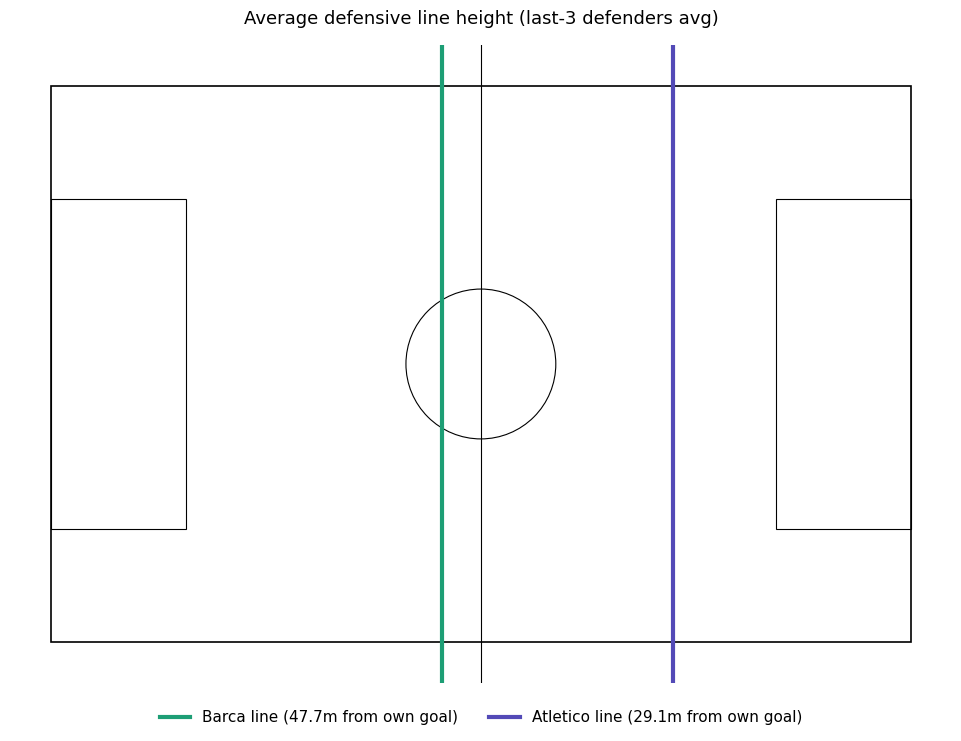

In [33]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

PITCH_LENGTH = 105
PITCH_WIDTH = 68

team0_line_x = avg_line_height[0]                # Barca, attacks +x, own goal at x=0
team1_line_x = PITCH_LENGTH - avg_line_height[1]  # Atletico, attacks -x, own goal at x=105

fig, ax = plt.subplots(figsize=(12, 7.5))

# Pitch outline
ax.add_patch(patches.Rectangle((0, 0), PITCH_LENGTH, PITCH_WIDTH, fill=False, color="black", linewidth=1.2))
ax.axvline(PITCH_LENGTH / 2, color="black", linewidth=0.8)
ax.add_patch(patches.Circle((PITCH_LENGTH / 2, PITCH_WIDTH / 2), 9.15, fill=False, color="black", linewidth=0.8))

# Penalty boxes (standard 16.5m x 40.3m, centered on goal)
box_depth, box_width = 16.5, 40.3
ax.add_patch(patches.Rectangle((0, (PITCH_WIDTH - box_width) / 2), box_depth, box_width, fill=False, color="black", linewidth=0.8))
ax.add_patch(patches.Rectangle((PITCH_LENGTH - box_depth, (PITCH_WIDTH - box_width) / 2), box_depth, box_width, fill=False, color="black", linewidth=0.8))

# Defensive lines
ax.axvline(team0_line_x, color="#1D9E75", linewidth=3, label=f"Barca line ({team0_line_x:.1f}m from own goal)")
ax.axvline(team1_line_x, color="#534AB7", linewidth=3, label=f"Atletico line ({avg_line_height[1]:.1f}m from own goal)")

ax.set_xlim(-5, PITCH_LENGTH + 5)
ax.set_ylim(-5, PITCH_WIDTH + 5)
ax.set_aspect("equal")
ax.axis("off")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.02), ncol=2, frameon=False, fontsize=11)
ax.set_title("Average defensive line height (last-3 defenders avg)", fontsize=13, pad=15)

plt.tight_layout()
plt.show()

In [34]:
FPS = 25
MAX_SEARCH_WINDOW_SEC = 10  # cap how far after losing the ball we look for a press to start
MAX_SEARCH_WINDOW_FRAMES = MAX_SEARCH_WINDOW_SEC * FPS

# Step 1: segment possession into continuous runs (bridge tiny None gaps, same pattern as before)
poss = ball_frame_table[["frame_idx", "possession_team"]].sort_values("frame_idx").reset_index(drop=True)
poss["state_change"] = (poss["possession_team"] != poss["possession_team"].shift()).cumsum()

poss_runs = (
    poss.groupby("state_change")
    .agg(start_frame=("frame_idx", "first"), end_frame=("frame_idx", "last"), possession_team=("possession_team", "first"))
    .reset_index(drop=True)
)
poss_runs = poss_runs.dropna(subset=["possession_team"]).reset_index(drop=True)

# Step 2: a "loss event" for team X = end of a run where team=X, immediately followed by a run where team=other
loss_events = []
for i in range(len(poss_runs) - 1):
    losing_team = poss_runs.loc[i, "possession_team"]
    gaining_team = poss_runs.loc[i + 1, "possession_team"]
    if losing_team != gaining_team:
        loss_events.append({
            "losing_team": losing_team,
            "loss_frame": poss_runs.loc[i, "end_frame"],
        })
loss_events = pd.DataFrame(loss_events)
print("total possession-loss events:", len(loss_events))
print(loss_events["losing_team"].value_counts())

# Step 3: for each loss event, find the first frame (within window) where losing_team is under_team_pressure
press_lookup = team_pressure_full.copy()
press_lookup["frac_tight_blocked"] = press_lookup["frac_tight_blocked"].fillna(0)
press_lookup["under_team_pressure"] = (
    (press_lookup["n_pressing"] >= 2) | (press_lookup["frac_tight_blocked"] >= 0.375)
)
press_lookup = press_lookup[["frame_idx", "team", "under_team_pressure"]]

results = []
for _, row in loss_events.iterrows():
    team_id = row["losing_team"]
    loss_frame = row["loss_frame"]
    window = press_lookup[
        (press_lookup["team"] == team_id) &
        (press_lookup["frame_idx"] >= loss_frame) &
        (press_lookup["frame_idx"] <= loss_frame + MAX_SEARCH_WINDOW_FRAMES) &
        (press_lookup["under_team_pressure"])
    ]
    if len(window) > 0:
        first_press_frame = window["frame_idx"].min()
        time_to_press_sec = (first_press_frame - loss_frame) / FPS
        results.append({"team": team_id, "loss_frame": loss_frame, "time_to_press_sec": time_to_press_sec})

time_to_press = pd.DataFrame(results)
print(f"\nloss events with a press detected within {MAX_SEARCH_WINDOW_SEC}s: {len(time_to_press)} / {len(loss_events)}")

print("\ntime-to-press stats by team (seconds):")
print(time_to_press.groupby("team")["time_to_press_sec"].agg(["mean", "median", "min", "max", "count"]))

total possession-loss events: 50
losing_team
1    25
0    25
Name: count, dtype: int64

loss events with a press detected within 10s: 44 / 50

time-to-press stats by team (seconds):
          mean  median   min   max  count
team                                     
0     1.527273    0.26  0.04  6.40     22
1     2.169091    0.44  0.04  8.32     22


In [35]:
# Sanity check: how much of the match actually has a possession label vs is null?
total_frames = ball_frame_table["frame_idx"].nunique()
labeled_frames = ball_frame_table["possession_team"].notna().sum()
print(f"labeled frames: {labeled_frames} / {total_frames} ({labeled_frames/total_frames*100:.1f}%)")

# Distribution of possession spell lengths (in seconds) - are they unrealistically long?
poss_runs["duration_sec"] = (poss_runs["end_frame"] - poss_runs["start_frame"] + 1) / FPS
print("\npossession spell duration stats (seconds):")
print(poss_runs["duration_sec"].describe())
print("\nlongest 10 spells:\n", poss_runs.nlargest(10, "duration_sec")[["start_frame", "end_frame", "possession_team", "duration_sec"]])

# Cross-check: raw carrier_team switches (UNSMOOTHED) - true lower bound on turnovers
raw_carrier = ball_frame_table.dropna(subset=["carrier_team"])[["frame_idx", "carrier_team"]].sort_values("frame_idx")
raw_carrier["carrier_change"] = raw_carrier["carrier_team"] != raw_carrier["carrier_team"].shift()
raw_switches = raw_carrier["carrier_change"].sum()
print(f"\nraw (unsmoothed) carrier team switches: {raw_switches}")

labeled frames: 38168 / 70326 (54.3%)

possession spell duration stats (seconds):
count     81.000000
mean      34.588642
std       44.874428
min        0.440000
25%        3.600000
50%       18.360000
75%       45.440000
max      232.680000
Name: duration_sec, dtype: float64

longest 10 spells:
     start_frame  end_frame  possession_team  duration_sec
26        20458      26274                0        232.68
43        46082      51346                1        210.60
41        41908      46070                0        166.52
23        17128      20198                1        122.84
35        33374      36044                0        106.84
32        29200      31672                1         98.92
36        36045      38466                1         96.88
15         7078       9473                1         95.84
17         9505      11577                0         82.92
62        57601      59519                0         76.76

raw (unsmoothed) carrier team switches: 200


In [36]:
MIN_HOLD_SEC = 0.5
MIN_HOLD_FRAMES = int(MIN_HOLD_SEC * FPS)

raw_carrier = ball_frame_table.dropna(subset=["carrier_team"])[["frame_idx", "carrier_team"]].sort_values("frame_idx").reset_index(drop=True)

# Segment into continuous carrier_team runs (raw, not possession-smoothed)
raw_carrier["state_change"] = (raw_carrier["carrier_team"] != raw_carrier["carrier_team"].shift()).cumsum()
carrier_runs = (
    raw_carrier.groupby("state_change")
    .agg(start_frame=("frame_idx", "first"), end_frame=("frame_idx", "last"), n_frames=("frame_idx", "count"), carrier_team=("carrier_team", "first"))
    .reset_index(drop=True)
)

# Keep only runs with a minimum hold duration - this is our "genuine possession" filter
stable_runs = carrier_runs[carrier_runs["n_frames"] >= MIN_HOLD_FRAMES].reset_index(drop=True)
print("stable carrier runs (>= 0.5s hold):", len(stable_runs))
print(stable_runs["n_frames"].describe() / FPS)  # duration in seconds

# Turnover = consecutive stable runs where carrier_team actually changes
turnovers = []
for i in range(len(stable_runs) - 1):
    losing_team = stable_runs.loc[i, "carrier_team"]
    gaining_team = stable_runs.loc[i + 1, "carrier_team"]
    if losing_team != gaining_team:
        turnovers.append({"losing_team": losing_team, "loss_frame": stable_runs.loc[i, "end_frame"]})

turnovers = pd.DataFrame(turnovers)
print("\ngenuine turnover events:", len(turnovers))
print(turnovers["losing_team"].value_counts())

stable carrier runs (>= 0.5s hold): 192
count     7.680000
mean      7.046042
std       9.503780
min       0.520000
25%       1.440000
50%       3.040000
75%       9.300000
max      80.600000
Name: n_frames, dtype: float64

genuine turnover events: 182
losing_team
1    91
0    91
Name: count, dtype: int64


In [38]:
MIN_HOLD_SEC = 1.5
MIN_HOLD_FRAMES = int(MIN_HOLD_SEC * FPS)

stable_runs = carrier_runs[carrier_runs["n_frames"] >= MIN_HOLD_FRAMES].reset_index(drop=True)

turnovers = []
for i in range(len(stable_runs) - 1):
    losing_team = stable_runs.loc[i, "carrier_team"]
    gaining_team = stable_runs.loc[i + 1, "carrier_team"]
    if losing_team != gaining_team:
        turnovers.append({"losing_team": losing_team, "loss_frame": stable_runs.loc[i, "end_frame"]})

turnovers = pd.DataFrame(turnovers)
print("genuine turnover events:", len(turnovers))
print(turnovers["losing_team"].value_counts())

# --- Recompute time-to-press against the corrected turnover events ---
MAX_SEARCH_WINDOW_SEC = 10
MAX_SEARCH_WINDOW_FRAMES = MAX_SEARCH_WINDOW_SEC * FPS

results = []
for _, row in turnovers.iterrows():
    team_id = row["losing_team"]
    loss_frame = row["loss_frame"]
    window = press_lookup[
        (press_lookup["team"] == team_id) &
        (press_lookup["frame_idx"] >= loss_frame) &
        (press_lookup["frame_idx"] <= loss_frame + MAX_SEARCH_WINDOW_FRAMES) &
        (press_lookup["under_team_pressure"])
    ]
    if len(window) > 0:
        first_press_frame = window["frame_idx"].min()
        results.append({"team": team_id, "loss_frame": loss_frame, "time_to_press_sec": (first_press_frame - loss_frame) / FPS})

time_to_press = pd.DataFrame(results)
print(f"\nturnovers with a press detected within {MAX_SEARCH_WINDOW_SEC}s: {len(time_to_press)} / {len(turnovers)}")
print("\ntime-to-press stats by team (seconds):")
print(time_to_press.groupby("team")["time_to_press_sec"].agg(["mean", "median", "min", "max", "count"]))

genuine turnover events: 108
losing_team
1    54
0    54
Name: count, dtype: int64

turnovers with a press detected within 10s: 88 / 108

time-to-press stats by team (seconds):
          mean  median   min   max  count
team                                     
0     3.280000    3.64  0.04  9.76     45
1     3.824186    2.60  0.04  9.08     43


In [39]:
# Check: is the turnover sequence essentially a strict alternation?
sequence = turnovers["losing_team"].tolist()
alternating = all(sequence[i] != sequence[i+1] for i in range(len(sequence)-1)) if len(sequence) > 1 else True
print("is losing_team sequence strictly alternating?", alternating)

# Also check stable_runs directly: how many consecutive SAME-team pairs got excluded as non-turnovers?
same_team_pairs = (stable_runs["carrier_team"] == stable_runs["carrier_team"].shift()).sum()
print("consecutive stable_runs with SAME team (excluded, not a turnover):", same_team_pairs, "/", len(stable_runs)-1)

is losing_team sequence strictly alternating? True
consecutive stable_runs with SAME team (excluded, not a turnover): 34 / 142
